In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Ingresando dataframe a la variable datos

In [3]:
datos = pd.read_csv('/content/flights_sample_3m.csv', engine='python');
datos.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977.0,1562.0,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790.0,1149.0,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977.0,459.0,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790.0,2295.0,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416.0,407.0,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138311 entries, 0 to 138310
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  138311 non-null  object 
 1   AIRLINE                  138311 non-null  object 
 2   AIRLINE_DOT              138310 non-null  object 
 3   AIRLINE_CODE             138310 non-null  object 
 4   DOT_CODE                 138310 non-null  float64
 5   FL_NUMBER                138310 non-null  float64
 6   ORIGIN                   138310 non-null  object 
 7   ORIGIN_CITY              138310 non-null  object 
 8   DEST                     138310 non-null  object 
 9   DEST_CITY                138310 non-null  object 
 10  CRS_DEP_TIME             138310 non-null  float64
 11  DEP_TIME                 134718 non-null  float64
 12  DEP_DELAY                134716 non-null  float64
 13  TAXI_OUT                 134677 non-null  float64
 14  WHEE

In [5]:
datos.describe(include = "all")

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,138311,138311,138310,138310,138310.000000,138310.000000,138310,138310,138310,138310,...,138310.000000,138308.000000,134363.000000,134363.000000,138310.000000,24521.000000,24521.000000,24521.000000,24521.000000,24521.000000
unique,1704,19,18,18,NaN,NaN,377,370,371,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2019-07-17,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,NaN,NaN,ATL,"Atlanta, GA",ATL,"Chicago, IL",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,132,26170,26170,26170,NaN,NaN,7222,7222,7166,7292,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,19979.032434,2515.815147,NaN,NaN,NaN,NaN,...,0.002176,142.265133,136.634379,112.279854,809.263488,25.463072,4.014722,12.943436,0.138086,25.461686
std,NaN,NaN,NaN,NaN,376.629861,1745.662048,NaN,NaN,NaN,NaN,...,0.046600,71.439370,71.551460,69.634294,587.422691,74.320348,33.690272,31.910931,3.200495,55.451786
min,NaN,NaN,NaN,NaN,19393.000000,1.000000,NaN,NaN,NaN,NaN,...,0.000000,20.000000,16.000000,8.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,19790.000000,1058.000000,NaN,NaN,NaN,NaN,...,0.000000,90.000000,84.000000,61.000000,377.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,19930.000000,2158.000000,NaN,NaN,NaN,NaN,...,0.000000,125.000000,120.000000,95.000000,651.000000,4.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,20368.000000,3787.000000,NaN,NaN,NaN,NaN,...,0.000000,172.000000,167.000000,142.000000,1046.000000,23.000000,0.000000,17.000000,0.000000,30.000000


Limpiando Datos

In [6]:
datos.isna().sum().sort_values(ascending=False)

,0
CANCELLATION_CODE,134665
DELAY_DUE_LATE_AIRCRAFT,113790
DELAY_DUE_CARRIER,113790
DELAY_DUE_SECURITY,113790
DELAY_DUE_NAS,113790
DELAY_DUE_WEATHER,113790
ARR_DELAY,3948
ELAPSED_TIME,3948
AIR_TIME,3948
WHEELS_ON,3685


In [7]:
datos.isna().sum().sort_values(ascending=False) * 100

,0
CANCELLATION_CODE,13466500
DELAY_DUE_LATE_AIRCRAFT,11379000
DELAY_DUE_CARRIER,11379000
DELAY_DUE_SECURITY,11379000
DELAY_DUE_NAS,11379000
DELAY_DUE_WEATHER,11379000
ARR_DELAY,394800
ELAPSED_TIME,394800
AIR_TIME,394800
WHEELS_ON,368500


In [8]:
datos['DEP_DELAY'] = datos['DEP_DELAY'].fillna(0)

In [9]:
datos[datos['CANCELLED'] == 1].isna().sum()

,0
FL_DATE,0
AIRLINE,0
AIRLINE_DOT,0
AIRLINE_CODE,0
DOT_CODE,0
FL_NUMBER,0
ORIGIN,0
ORIGIN_CITY,0
DEST,0
DEST_CITY,0


Separar los vuelos separados

In [10]:
vuelos_cancelados = datos.loc[datos['CANCELLED'] == 1].copy()
vuelos_operados = datos.loc[datos['CANCELLED'] == 0].copy()
vuelos_operados['FL_DATE'] = pd.to_datetime(vuelos_operados['FL_DATE'], errors='coerce')

In [11]:
# Verificando si hay fechas invalidas (NaT) despues de la conversion
vuelos_operados[vuelos_operados['FL_DATE'].isna()]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT


In [12]:
#retrasos
vuelos_operados[
    (vuelos_operados['DEP_DELAY'] < -60) |
    (vuelos_operados['DEP_DELAY'] > 1000)
]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
29,2023-04-15,Republic Airline,Republic Airline: YX,YX,20452.0,3615.0,MSP,"Minneapolis, MN",EWR,"Newark, NJ",...,0.0,178.0,233.0,145.0,1008.0,0.0,0.0,1124.0,0.0,0.0
3639,2021-12-30,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790.0,696.0,SLC,"Salt Lake City, UT",LAX,"Los Angeles, CA",...,0.0,120.0,125.0,90.0,590.0,1022.0,0.0,5.0,0.0,0.0
4548,2019-12-20,American Airlines Inc.,American Airlines Inc.: AA,AA,19805.0,1646.0,RSW,"Fort Myers, FL",CLT,"Charlotte, NC",...,0.0,120.0,105.0,83.0,600.0,1020.0,0.0,0.0,0.0,0.0
5147,2021-02-01,American Airlines Inc.,American Airlines Inc.: AA,AA,19805.0,2228.0,CLT,"Charlotte, NC",EWR,"Newark, NJ",...,0.0,117.0,122.0,76.0,529.0,0.0,1180.0,5.0,0.0,0.0
13746,2021-10-04,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304.0,3230.0,SEA,"Seattle, WA",LAX,"Los Angeles, CA",...,0.0,169.0,162.0,136.0,954.0,0.0,0.0,0.0,0.0,1049.0
16537,2023-06-29,American Airlines Inc.,American Airlines Inc.: AA,AA,19805.0,793.0,ORD,"Chicago, IL",CLT,"Charlotte, NC",...,0.0,120.0,101.0,76.0,599.0,1541.0,0.0,0.0,0.0,0.0
29634,2022-03-07,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304.0,3065.0,TUL,"Tulsa, OK",AUS,"Austin, TX",...,0.0,88.0,100.0,80.0,426.0,0.0,0.0,0.0,0.0,1024.0
29661,2019-06-11,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304.0,5743.0,BOI,"Boise, ID",SFO,"San Francisco, CA",...,0.0,110.0,129.0,95.0,522.0,1155.0,0.0,19.0,0.0,0.0
29721,2023-06-02,American Airlines Inc.,American Airlines Inc.: AA,AA,19805.0,868.0,OKC,"Oklahoma City, OK",DFW,"Dallas/Fort Worth, TX",...,0.0,67.0,81.0,31.0,175.0,1093.0,0.0,14.0,0.0,0.0
34963,2021-11-07,SkyWest Airlines Inc.,SkyWest Airlines Inc.: OO,OO,20304.0,3076.0,DSM,"Des Moines, IA",ORD,"Chicago, IL",...,0.0,90.0,74.0,54.0,299.0,0.0,0.0,0.0,0.0,1075.0


In [13]:
vuelos_operados[
    (vuelos_operados['DISTANCE'] <= 0) |
    (vuelos_operados['DISTANCE'] > 15000)
]

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT


## Tipo de dato distancia

#### La variable distance se encuentra el millas

In [14]:
vuelos_operados['DISTANCE'].describe()

,DISTANCE
count,134664.000000
mean,810.999703
std,588.936166
min,29.000000
25%,378.000000
50%,655.000000
75%,1047.000000
max,5095.000000


## Convirtiendo a Kilometros

In [15]:
vuelos_operados['DISTANCE_KM'] = vuelos_operados['DISTANCE'] * 1.60934
vuelos_operados['DISTANCE_KM'].describe()

,DISTANCE_KM
count,134664.000000
mean,1305.174262
std,947.798529
min,46.670860
25%,608.330520
50%,1054.117700
75%,1684.978980
max,8199.587300


## Graficando

### Cancelaciones por aerolinea (en caso de que sea relevante)

<Axes: xlabel='AIRLINE'>

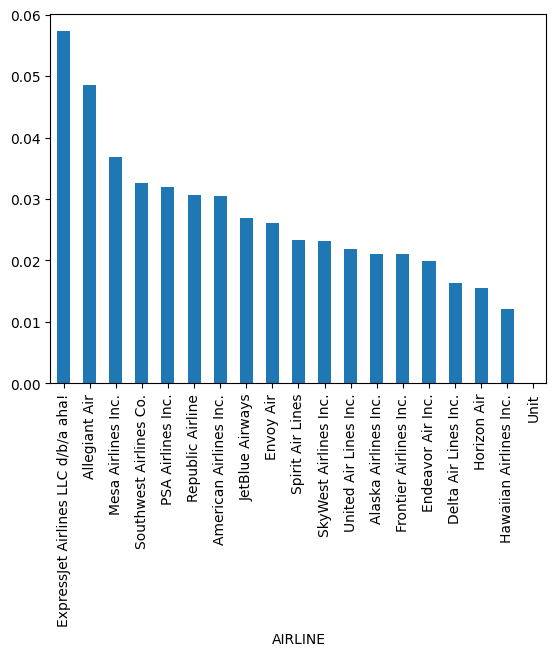

In [16]:
tasa_cancelacion = (
    datos.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False)
)
tasa_cancelacion.plot(kind='bar')

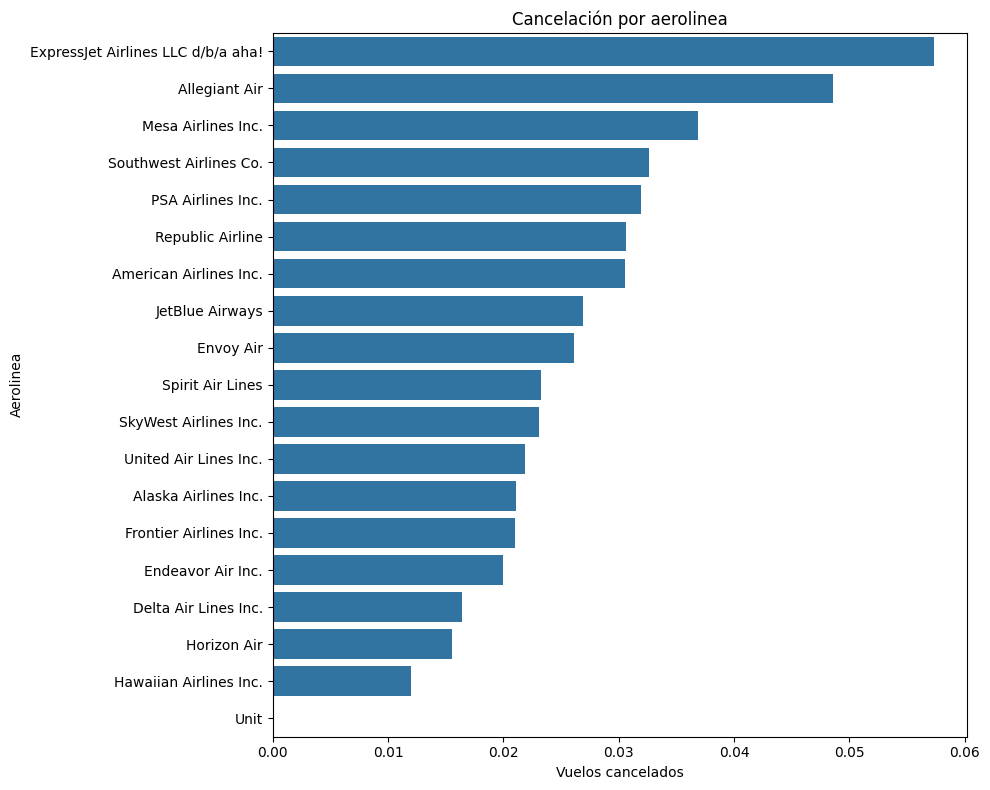

In [17]:
plt.figure(figsize=(10,8))
sns.barplot(
    y=tasa_cancelacion.index,
    x=tasa_cancelacion.values,
    orient='h'
)
plt.title("Cancelación por aerolinea")
plt.xlabel("Vuelos cancelados")
plt.ylabel("Aerolinea")
plt.tight_layout()
plt.show()

### Retrasos por aerolinea

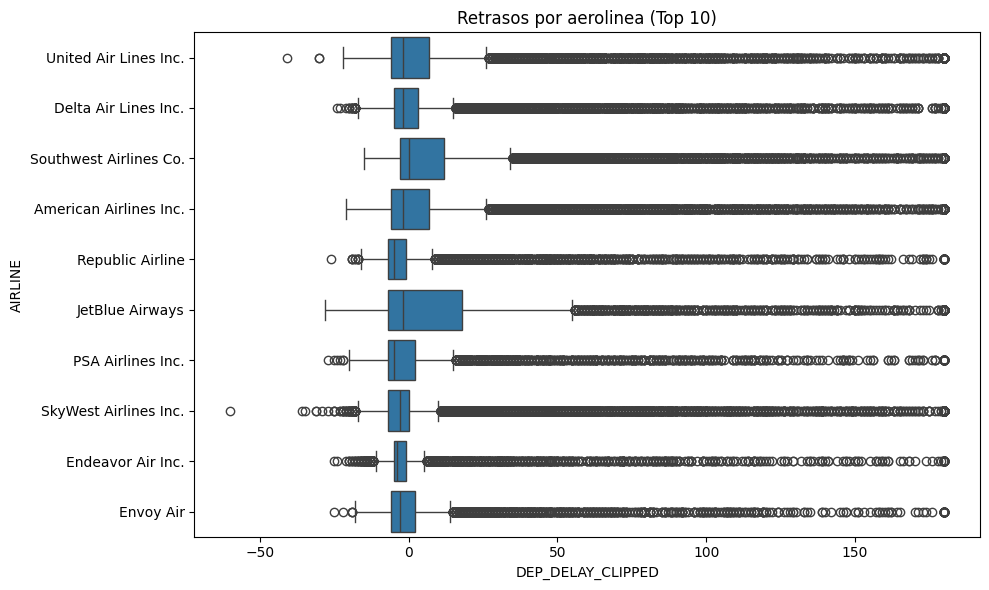

In [18]:
top_aerolineas = (vuelos_operados['AIRLINE'].value_counts().head(10).index)

datos_top = vuelos_operados[vuelos_operados['AIRLINE'].isin(top_aerolineas)].copy()

datos_top.loc[:, 'DEP_DELAY_CLIPPED'] = datos_top['DEP_DELAY'].clip(lower=-60, upper=180)

plt.figure(figsize=(10,6))
sns.boxplot(data=datos_top, y='AIRLINE', x='DEP_DELAY_CLIPPED')
plt.title('Retrasos por aerolinea (Top 10)')
plt.tight_layout()
plt.show()

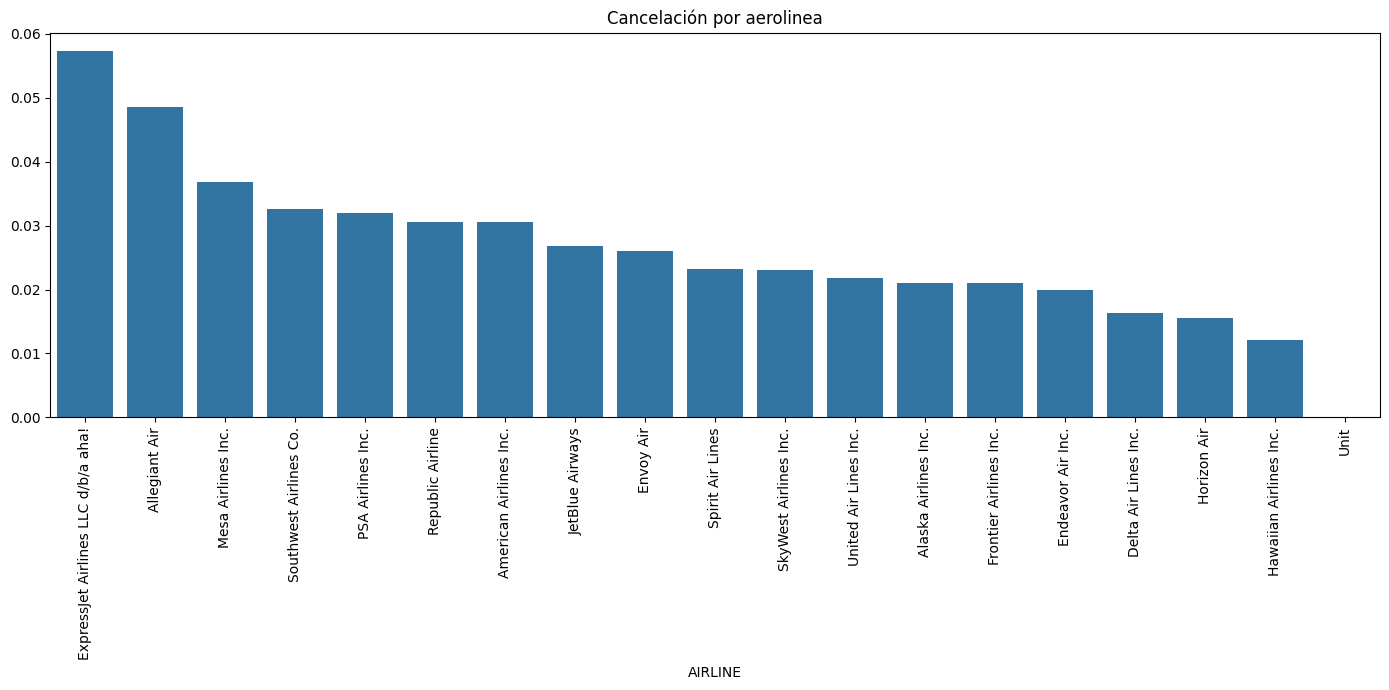

In [19]:
# En graficas en vertical

plt.figure(figsize=(14,7))
sns.barplot(x=tasa_cancelacion.index, y=tasa_cancelacion.values)
plt.xticks(rotation=90)
plt.title('Cancelación por aerolinea')
plt.tight_layout()
plt.show()

In [20]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138311 entries, 0 to 138310
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  138311 non-null  object 
 1   AIRLINE                  138311 non-null  object 
 2   AIRLINE_DOT              138310 non-null  object 
 3   AIRLINE_CODE             138310 non-null  object 
 4   DOT_CODE                 138310 non-null  float64
 5   FL_NUMBER                138310 non-null  float64
 6   ORIGIN                   138310 non-null  object 
 7   ORIGIN_CITY              138310 non-null  object 
 8   DEST                     138310 non-null  object 
 9   DEST_CITY                138310 non-null  object 
 10  CRS_DEP_TIME             138310 non-null  float64
 11  DEP_TIME                 134718 non-null  float64
 12  DEP_DELAY                138311 non-null  float64
 13  TAXI_OUT                 134677 non-null  float64
 14  WHEE

## Feature engeeniering

Extracción  de variables de fecha y hora

In [21]:
#Hora del día
#Dividimos DEP_TIME por 100 para obtener la hora y luego rellenamos nulos
vuelos_operados['DEP_TIME_HOUR'] = (vuelos_operados['DEP_TIME'] // 100).fillna(0).astype(int)

#Día de la semana
#Para que dt.dayofweek nos devuelva 0 = Lunes, 1 = Martes, 2 Miércoles ... 6 = domingo
print(f"FL_DATE dtype before .dt accessor: {vuelos_operados['FL_DATE'].dtype}")
vuelos_operados['DAY_OF_WEEK'] = vuelos_operados['FL_DATE'].dt.dayofweek

#Mes del año
#Extraemos el mes (1=Enero | 12=Diciembre)
vuelos_operados['MONTH'] = vuelos_operados['FL_DATE'].dt.month  #Añadido el 22-12-2025

print("Ejemplo de nuevas variables temporales:")
print(vuelos_operados[['FL_DATE', 'DEP_TIME', 'DEP_TIME_HOUR', 'DAY_OF_WEEK', 'MONTH']].head())

FL_DATE dtype before .dt accessor: datetime64[ns]
Ejemplo de nuevas variables temporales:
     FL_DATE  DEP_TIME  DEP_TIME_HOUR  DAY_OF_WEEK  MONTH
0 2019-01-09    1151.0             11            2      1
1 2022-11-19    2114.0             21            5     11
2 2022-07-22    1000.0             10            4      7
3 2023-03-06    1608.0             16            0      3
4 2020-02-23    1838.0             18            6      2


Codificación de variables categóricas (Label Encoding)

In [22]:
#Iniciamos los codificadores respectivos
le_aerolinea = LabelEncoder()
le_origen = LabelEncoder()
le_destino = LabelEncoder()

#Entrenamos y transformamos al mismo tiempo
vuelos_operados['aerolinea_encoded'] = le_aerolinea.fit_transform(vuelos_operados['AIRLINE_CODE'])
vuelos_operados['origen_encoded'] = le_origen.fit_transform(vuelos_operados['ORIGIN'])
vuelos_operados['destino_encoded'] = le_destino.fit_transform(vuelos_operados['DEST'])

#Guardamos los encoders para el equipo de Backend
joblib.dump(le_aerolinea, 'le_aerolinea.joblib')
joblib.dump(le_origen, 'le_origen.joblib')
joblib.dump(le_destino, 'le_destino.joblib')

print("Ejemplo de nuevas variables codificadas:")
print(vuelos_operados[['AIRLINE_CODE', 'aerolinea_encoded', 'ORIGIN', 'origen_encoded', 'DEST', 'destino_encoded']].head())



Ejemplo de nuevas variables codificadas:
  AIRLINE_CODE  aerolinea_encoded ORIGIN  origen_encoded DEST  destino_encoded
0           UA                 14    FLL             130  EWR              119
1           DL                  4    MSP             245  SEA              315
2           UA                 14    DEN              98  MSP              241
3           DL                  4    MSP             245  SFO              317
4           NK                 10    MCO             221  DFW               96


Validación final con el contrato

In [23]:
#Definimos las columnas esenciales para el modelo
columnas_esenciales = [
    'DEP_TIME_HOUR',
    'DAY_OF_WEEK',
    'MONTH',             #Añadido el 22-12-2025
    'aerolinea_encoded',
    'origen_encoded',
    'destino_encoded',
    'DISTANCE_KM']

#Verificamos si existen en nuestra tabla de 'vuelos_operados'
missing_cols = [col for col in columnas_esenciales if col not in vuelos_operados.columns]

print("---REPORTE DE VALIDACIÓN---")
if not missing_cols:
    print("OK, todas las columnas están listas.")
    print("El dataset cumple con el contrato para entrar el modelo")
    print(f"Columnas finales para el modelo (nombre del modelo): {columnas_esenciales}")
else:
    print("ERROR, faltan las siguientes columnas:", missing_cols)

---REPORTE DE VALIDACIÓN---
OK, todas las columnas están listas.
El dataset cumple con el contrato para entrar el modelo
Columnas finales para el modelo (nombre del modelo): ['DEP_TIME_HOUR', 'DAY_OF_WEEK', 'MONTH', 'aerolinea_encoded', 'origen_encoded', 'destino_encoded', 'DISTANCE_KM']


Diccionario con los números a códigos de líneas aéreas

In [24]:
#Obtenemos las clases (los códigos originales ordenados)
#El índice de la lista es el número asignado por el encoder.
codigos = le_aerolinea.classes_

#Creamos el diccionario: { Número : "Código" }
diccionario_num_a_codigo = {i: codigo for i, codigo in enumerate(codigos)}

#Creamos el diccionario inverso: { "Código" : Número }
diccionario_codigo_a_num = {codigo: i for i, codigo in enumerate(codigos)}

print("--- Diccionario: Número -> Aerolínea ---")
print(diccionario_num_a_codigo)

print("\n--- Diccionario: Aerolínea -> Número (Para la API) ---")
print(diccionario_codigo_a_num)

#'Opcional: Exportar a un archivo JSON real si el equipo de Backend lo prefiere'
import json
with open('mapa_aerolineas.json', 'w') as f:
    json.dump(diccionario_codigo_a_num, f)
    print("\n✅ Archivo 'mapa_aerolineas.json' exportado exitosamente.")

--- Diccionario: Número -> Aerolínea ---
{0: '9E', 1: 'AA', 2: 'AS', 3: 'B6', 4: 'DL', 5: 'EV', 6: 'F9', 7: 'G4', 8: 'HA', 9: 'MQ', 10: 'NK', 11: 'OH', 12: 'OO', 13: 'QX', 14: 'UA', 15: 'WN', 16: 'YV', 17: 'YX'}

--- Diccionario: Aerolínea -> Número (Para la API) ---
{'9E': 0, 'AA': 1, 'AS': 2, 'B6': 3, 'DL': 4, 'EV': 5, 'F9': 6, 'G4': 7, 'HA': 8, 'MQ': 9, 'NK': 10, 'OH': 11, 'OO': 12, 'QX': 13, 'UA': 14, 'WN': 15, 'YV': 16, 'YX': 17}

✅ Archivo 'mapa_aerolineas.json' exportado exitosamente.


Diccionario general que vinculan los códigos originales de las aerolíneas y aeropuertos con los identificadores numéricos generados por los LabelEncoder.

-Este "mapa de traducción" que permite que el microservicio convierta instantáneamente las entradas de texto del usuario en los valores exactos que el modelo requiere para procesar la predicción.

-Al exportar estas equivalencias y los codificadores mediante archivos .joblib, se garantiza que el sistema hable un único idioma técnico y elimino cualquier riesgo de error en la comunicación de datos entre la API y el modelo entrenado.

### Determinación del Target del Modelo

Para este proyecto, el objetivo es predecir si un vuelo saldrá con retraso.  
Para ello, se definio un **target binario** basado en la variable `DEP_DELAY`, que indica los minutos de retraso en la salida del vuelo.

### Estándar utilizado
De acuerdo con la normativa internacional (DOT/IATA), un vuelo se considera **retrasado** cuando presenta **15 minutos o más de demora** en la salida.

### Definición del target
- **1** → Vuelo retrasado (`DEP_DELAY ≥ 15`)
- **0** → Vuelo a tiempo (`DEP_DELAY < 15`)

Esta definición permite entrenar un modelo de clasificación capaz de entregar la **probabilidad de retraso**, que es el resultado requerido por el cliente y utilizado por el frontend del proyecto.

### Validación y preparación de la variable base `DEP_DELAY`

Antes de construir el target, es necesario asegurar que la variable `DEP_DELAY` esté en condiciones de ser utilizada.  
Para ello, se realiza lo siguiente:

- Se trabaja únicamente con vuelos operados (no cancelados ni desviados), ya que en esos casos no es posible determinar un retraso real en la salida.
- Se excluyen registros sin información en `DEP_DELAY`, dado que no permiten clasificar el vuelo como retrasado o a tiempo.
- Se verifica que los valores extremos o inconsistentes sean mínimos y no afecten la definición del target.

Este proceso garantiza que el target se construya sobre datos válidos y coherentes con la operación real.

In [25]:
# Filtrar solo vuelos operados (no cancelados ni desviados)
vuelos_operados = datos.loc[
    (datos['CANCELLED'] == 0) &
    (datos['DIVERTED'] == 0)
].copy()

# Eliminar registros sin DEP_DELAY
vuelos_operados = vuelos_operados[~vuelos_operados['DEP_DELAY'].isna()].copy()

# Crear el target binario
vuelos_operados['DELAYED'] = (vuelos_operados['DEP_DELAY'] >= 15).astype(int)

# Revisión rápida del balance de clases
vuelos_operados['DELAYED'].value_counts(normalize=True)

,proportion
DELAYED,
0,0.819139
1,0.180861


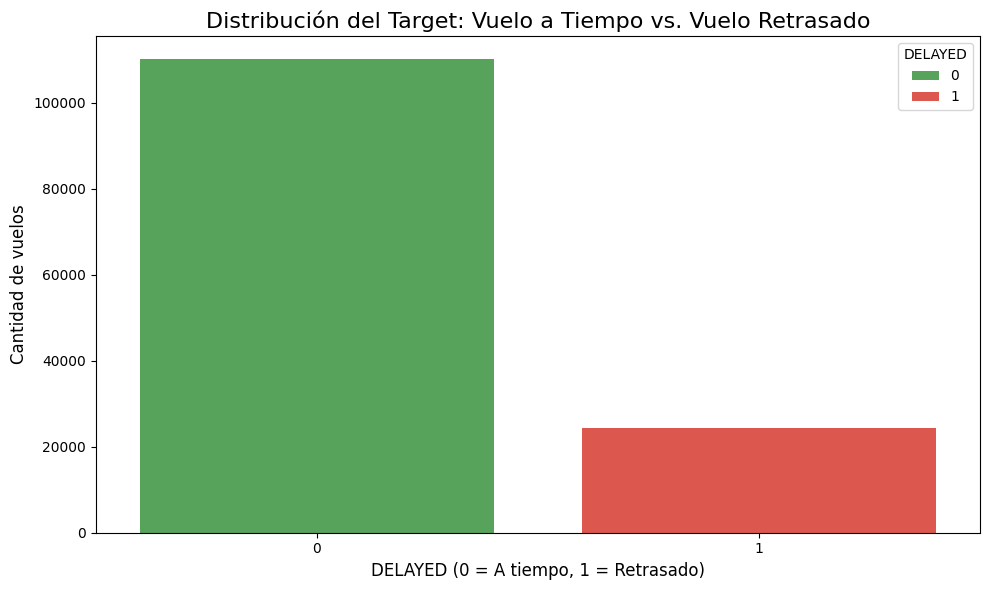

In [26]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='DELAYED',
    hue='DELAYED',
    data=vuelos_operados,
    palette=['#4CAF50', '#F44336']  # Verde = a tiempo, rojo = retrasado
   )

plt.title('Distribución del Target: Vuelo a Tiempo vs. Vuelo Retrasado', fontsize=16)
plt.xlabel('DELAYED (0 = A tiempo, 1 = Retrasado)', fontsize=12)
plt.ylabel('Cantidad de vuelos', fontsize=12)

plt.tight_layout()
plt.show()

### Interpretación del gráfico

En el gráfico se puede ver claramente cómo se distribuyen los vuelos entre aquellos que salen a tiempo (`DELAYED = 0`) y los que presentean un retraso de 15 minutos o más (`DELAYED = 1`).

La revisión es fundamental porque:

- Permite detectar si existe un desbalance entre ambasclases, algo que más adelante influirá en las métricas y en las decisiones de modelado.
- También confirma que la construcción del target es coherente con los datos disponibles.
- Además asegura que el modelo se entrenará con información representativa de la operación real, lo que aumenta la confiabilidad de los resultados.

Con esta etapa, la determinación del target queda completamente definida y validada.


\#Entrenamiento del modelo.


##Importacion de las librerias necesarias.

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [28]:
vuelos_operados['DISTANCE_KM'] = vuelos_operados['DISTANCE'] * 1.60934
vuelos_operados['DISTANCE_KM'].head()

,DISTANCE_KM
0,1713.94710
1,2251.46666
2,1094.35120
3,2557.24126
4,1585.19990


In [29]:
#Se busca una columna la cual contenga datos de los retrasos.
columna_retraso = 'ARR_DELAY' if 'ARR_DELAY' in vuelos_operados.columns else [c for c in vuelos_operados.columns if 'DELAY' in c][0]

#Se separan las columnas que se utilizaran para los modelos.
cols_existentes = [c for c in ['AIRLINE', 'ORIGIN', 'DEST', 'DISTANCE_KM', 'DAY_OF_WEEK'] if c in vuelos_operados.columns]
columnas_finales = cols_existentes + [columna_retraso]

#Se crea el dataframe con el que se va a trabajar, eliminando nulos.
df_trabajo = vuelos_operados[columnas_finales].dropna().copy()

#Se fuerza la conversión a número para evitar el errores con los tipos en las columnas de datos.
for col in ['DISTANCE_KM', 'DAY_OF_WEEK', columna_retraso]:
    if col in df_trabajo.columns:
        df_trabajo[col] = pd.to_numeric(df_trabajo[col], errors='coerce')

#Se eliminan los valores nulos para el data frame final.
df_trabajo = df_trabajo.dropna()

#Se definen los datos para X y los datos para y.
y = (df_trabajo[columna_retraso] > 15).astype(int)
X = df_trabajo[cols_existentes].copy()

#Se codifican las categorías.
le = LabelEncoder()
for col in ['AIRLINE', 'ORIGIN', 'DEST','DISTANCE_KM']:
    if col in X.columns:
        X[col] = le.fit_transform(X[col].astype(str))

print("Realizado correctamente")
print(f"Registros finales para entrenar el modelo: {len(X)}")
X.head()

Realizado correctamente
Registros finales para entrenar el modelo: 134363


,AIRLINE,ORIGIN,DEST,DISTANCE_KM
0,17,130,119,437
1,3,245,315,700
2,17,98,241,56
3,3,245,317,816
4,16,221,96,357


##Separación de los datos de entrenamiento y prueba para el modelo.

Se hara una separación del 80% de los datos para el entrenamiento del modelo y el 20% de los datos para la prueba del modelo.

Estos datos que se separan son los datos que se limpiaron, eliminaron o agregaron columnas consideradas necesarias para la creación de modelo.

In [30]:
#Separación de los datos de entrenamiento y prueba, 80% para entrenamiento y 20% para prueba de los modelos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Modelo de Logistic Regression.


In [31]:
# Modelo 1: Logistic Regression (Modelo simple)
modelo_log = LogisticRegression(max_iter=500, solver='liblinear')
modelo_log.fit(X_train, y_train)
print("Modelo de Logistic Regression entrenado correctamente.")

Modelo de Logistic Regression entrenado correctamente.


##Modelo de Random Forest

In [32]:
# Modelo 2: Random Forest (Ajuste básico)
modelo_rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
print("Modelo de Random Forest entrenado correctamente.")

Modelo de Random Forest entrenado correctamente.


#Evaluación de los modelos.

##Importación de librerias necesarias para las pruebas.


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

##Definición de una función para las pruebas.

In [34]:
#Se crea una función para calcular cada una de las distintas variables(Accuaracy, Precision, Recall, F1-score).
#Esto se crea, para realizar las pruebas de forma más sencilla.
def evaluar_modelo(nombre, modelo, X_test, y_test):
    predicciones = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, predicciones),
        'Precision': precision_score(y_test, predicciones),
        'Recall': recall_score(y_test, predicciones),
        'F1-score': f1_score(y_test, predicciones)
    }

##Evalución de los modelos de predicción

In [35]:
res_log = evaluar_modelo('Logistic Regression', modelo_log, X_test, y_test)
res_rf = evaluar_modelo('Random Forest', modelo_rf, X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Resultados de las pruebas de los modelos.


In [36]:
df_resultados = pd.DataFrame([res_log, res_rf])
print(df_resultados)

                Modelo  Accuracy  Precision    Recall  F1-score
0  Logistic Regression  0.823615        0.0  0.000000  0.000000
1        Random Forest  0.823578        0.4  0.000422  0.000843
